### Plot PyMOL alignment performance
### Julian Moran
### 2026-02-24

In [11]:
import logging
import os

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path

import polars as pl
import numpy as np

# Env
load_dotenv("../.env", override=True)
INSTALL_PATH = os.environ["INSTALL_PATH"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

In [20]:
# ============================================================
#                               Args
# ============================================================

args = {
    "data_file_pm_al": f"{INSTALL_PATH}/results/test_pymol_align/pymol_alignment_performance.tsv",
    "threshold_rmsd": 3.0,
    "col_pm_rmsd": "PyMOL_RMSD",
    "out_dir": Path(f"{INSTALL_PATH}/vis/plots")
}

args["out_dir"].mkdir(parents=True, exist_ok=True)

In [9]:
# ============================================================
#                              In
# ============================================================

df_pm_al = pl.read_csv(
    args["data_file_pm_al"],
    separator="\t",
    has_header=True
)

df_pm_al

defense_system_protein_id,protein_id,defense_system_protein_AF_file,protein_AF_file,PyMOL_aligned_filePath,PyMOL_RMSD,PyMOL_aligned_atoms
str,str,str,str,str,f64,i64
"""A0A1Y6A5H7""","""A0A6Q8PGV8""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",47.249104,2855
"""A0A556BFS8""","""A0A6Q8PFJ4""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",49.968063,2895
"""Q9RFR9""","""O95140""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",36.457573,3015
"""A0A556BFS8""","""A0A6Q8PGA3""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",30.233805,1927
"""Q9RFR9""","""A0A6Q8PGA3""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",43.934452,2610
…,…,…,…,…,…,…
"""Q3Y0J6""","""O43598""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",7.098107,145
"""A0A829F2V1""","""O43598""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",7.067309,145
"""A0A6P1GFG5""","""Q17R31""","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",1.907084,906


INFO:__main__:Percent protein pairs with alignment <= 3.0: 27.27%
INFO:__main__:PyMOL_RMSD max: 69.8252
INFO:__main__:PyMOL_RMSD min: 0.6381


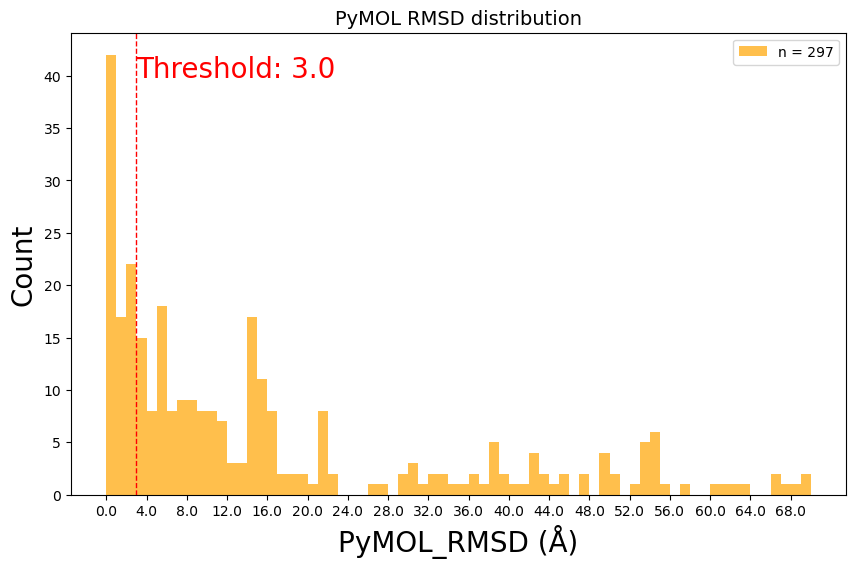

In [30]:
# ============================================================
#                             Plot hist
# ============================================================

def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None


def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        threshold_ann_side: str = "left",
        dims: tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:
    
    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    logger.info(f"{col_name} max: {round(max, 4):,}")
    logger.info(f"{col_name} min: {round(min, 4):,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        logger.info(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        logger.info(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{round(x, 2):,}"

    l = np.floor(min / tick_interval) * tick_interval
    u = np.ceil(max / tick_interval) * tick_interval
    xticks = np.arange(l, u, tick_interval)

    l = np.floor(min / bin_width) * bin_width
    u = np.ceil(max / bin_width) * bin_width
    edges = np.arange(l, u + bin_width, bin_width)

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if threshold is not None:
        ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1)
        if threshold_ann is None:
            threshold_ann = f"Threshold: {threshold}"
        ax.text(threshold, ax.get_ylim()[1]*0.95, threshold_ann, color="red", ha=threshold_ann_side, va="top", fontsize=axis_label_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

# Compute percentage less than threshold
pm_al_good = df_pm_al.filter(
    (pl.col(args["col_pm_rmsd"]) <= args["threshold_rmsd"])
)
pm_al_good = (len(pm_al_good)/(len(df_pm_al))) * 100
logger.info(f"Percent protein pairs with alignment <= {args['threshold_rmsd']}: {round(pm_al_good, 2):,}%")

# Display hist
plot_hist(
    df=df_pm_al,
    col_name=args["col_pm_rmsd"],
    colour="orange",
    bin_width=1.0,
    tick_interval=4.0,
    threshold=args["threshold_rmsd"],
    title="PyMOL RMSD distribution",
    xlabel=f"{args['col_pm_rmsd']} (Å)",
    axis_label_fontSize=20,
    out_path=f"{args['out_dir']}/PyMOL_rmsd_n={len(df_pm_al)}"
)

```Python
plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        threshold_ann_side: str = "left",
        dims: tuple[int, int] = (10, 6),
        out_path: str = None
)
```